[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# A 2-D truss sizing optimization: Manufacturing constraints.

Last updated: 06/27/26

## Description

Optimize the cross sectional properties of a truss structure to achieve its 
minimum weight. The bars are manufactured out of square hollow tubes.
Manufacturing constraints are added such that the thickness of the wall
must be greater then 1/10 of the inner dimension. This is typically done to ensure that
the walls of the steel tubes are sufficiently robust at the joints.

The bars are grouped into four groups: bottom chord, top chord,
verticals, and diagonals. Each group has its own individual
cross sectional properties.

Objective function: mass of the structure. The design variables are the 
inner dimension and thickness of the wall for each group of bars.

Constraints: (1) limit on maximum deflection, (2) the bars must remain elastic (i.e. there must be no yielding),
(3) the bars in compression must not buckle,  (4) the design variables 
are bounded from below so that the thickness of the wall 
and the inner dimension must both be greater than equal to  given constants. This constraint is
a lower bound on the design variables. Finally, there is a (5) manufacturing constraint 
that specifies that the thickness of the wall must be greater than some fraction of the inner dimension.

Mathematically
$$
       x^* = \arg\min f(x)
$$
subject to the constraint
$$
    c_j(x) \ge 0 \; , j=1,5
$$
Note: $f(x)$ is the objective function, whose argument is the vector of the design variables, $x$.


## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


First we bring in the modules and functions that we will need.

In [22]:
import scipy
import context
from math import pi
from numpy import max, ones, zeros, inf, minimum
from pystran import model
from pystran import section
from pystran import truss
from pystran import geometry
from pystran import plots
from scipy.optimize import minimize

We are working in SI(mm) units. Next, we define some useful constants.

Initially, all members have cross sections of minimal dimensions. The design variables are multiples of these dimensions.

The minimum wall thickness and the smallest inner dimension are given.
These constraints will be enforced by the "lower bound" constraints on the design variables defined below.

In [23]:
INNER_DIM_MIN = 12.0
THICKNESS_MIN = 0.5

The manufacturing constraints need to ensure that the wall doesn't get too thin. The minimum ratio of the wall thickness to the inner dimension is

In [24]:
MINIMUM_THICKNESS_DIMENSION_RATIO = 1/10


Maximum allowed deflection (in millimeters)


In [25]:
MAXIMUM_ALLOWED_DEFLECTION = 10.0


The material properties correspond roughly to steel. The yield stress is given. 


In [26]:
E = 200000
RHO = 8.0e-9
sigy = E / 1000


The magnitude of the vertical (downward) forces in Newton.


In [27]:
W = 6000

The design variables are nondimensional multipliers of the minimum inner dimension of each group, followed by the nondimensional multipliers of the minimum wall thickness of each group. So the design variables will have to assume values greater than or equal to one.

The functions to calculate the area of a bar and its moment of area use the  nondimensional values of the design variables, the first for the inner dimension and the second for the wall thickness, to calculate the real radius and wall thickness, and then the area.

In [28]:
def _area(nd, nt):
    d = INNER_DIM_MIN * nd
    t = THICKNESS_MIN * nt
    return (d + 2*t)**2 - d**2 

def _second_moment(nd, nt):
    d = INNER_DIM_MIN * nd
    t = THICKNESS_MIN * nt
    return ((d + 2*t)**4 - d**4) / 12

Next we define the groups of bars.

In [29]:
group_names = ["bottom_chord", "top_chord", "verticals", "diagonals"]
NGROUPS = len(group_names)
group_bars = [
    [ # bottom_chord
        [1, 2],
        [2, 3],
        [3, 4],
        [4, 5],
    ],
    [ # top_chord
        [6, 7],
        [7, 8],
        [8, 9],
        [9, 10],
    ],
    [ # verticals
        [1, 6],
        [2, 7],
        [3, 8],
        [4, 9],
        [5, 10],
    ],
    [ # diagonals
        [1, 7],
        [3, 9],
        [3, 7],
        [5, 9],
    ]
    ]


The cross sectional area of each group of bars is `_area(dvs[i], dvs[i+NGROUPS])`. The design variables start 
at the value of 1.0. In other words, the inner dimension of the tube is the smallest allowed, and the thickness of the tube wall is also the minimum allowed.

In [30]:
dvs0 = ones(2 * NGROUPS)

This function defines the `pystran` model of the structure, based on the values of the
design variables, `dvs`. Note that we store also the second moment of area to enable the definition of buckling constraints.


In [31]:
def truss_model(dvs):
    m = model.create(2)
    freedoms = m['freedoms']
    model.add_joint(m, 1, [-6000, -2500])
    model.add_joint(m, 2, [-3000, -2500])
    model.add_joint(m, 3, [0, -2500])
    model.add_joint(m, 4, [3000, -2500])
    model.add_joint(m, 5, [6000, -2500])
    model.add_joint(m, 6, [-6000, 0])
    model.add_joint(m, 7, [-3000, 0])
    model.add_joint(m, 8, [0, 0])
    model.add_joint(m, 9, [3000, 0])
    model.add_joint(m, 10, [6000, 0])
    model.add_support(m["joints"][1], freedoms.U2)
    model.add_support(m["joints"][5], freedoms.U2)
    model.add_support(m["joints"][8], freedoms.U1)
    model.add_load(m["joints"][2], freedoms.U2, -W)
    model.add_load(m["joints"][3], freedoms.U2, -W)
    model.add_load(m["joints"][4], freedoms.U2, -W)
    for g in range(NGROUPS):
        s = section.truss_section(g, E=E, A=_area(dvs[g], dvs[g+NGROUPS]), rho=RHO)
        s['I'] = _second_moment(dvs[g], dvs[g+NGROUPS])
        for k, c in enumerate(group_bars[g]):
            model.add_truss_member(m, f"{group_names[g]}_{k}", c, s)
    return m

At this point we can display the initial structure: members, joints, applied forces, and supports.


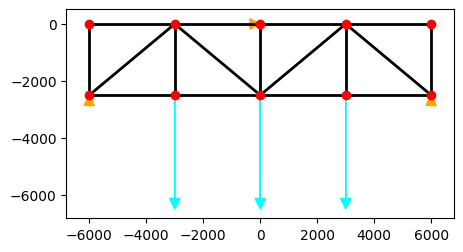

In [32]:
m = truss_model(dvs0)
plots.setup(m)
plots.plot_members(m)
plots.plot_joints(m)
plots.plot_applied_forces(m)
plots.plot_translation_supports(m)
plots.show(m)

The following calculates the total volume of all 
the members of the structure. We can use it to evaluate 
the total mass of the structure. 


In [33]:
mass = RHO * model.volume(m)
print('Initial mass = ', 1000 * mass, ' [kg]')

Initial mass =  10.424099870362664  [kg]


The `solve` helper function is defined to compute the design 
responses (`drs`). Static response of the structure is computed. 

The design  responses are the mass of the structure and  the maximum displacement magnitude. They are returned as a tuple.

For each member we compute an array of buckling and yielding constraints.
The buckling constraint is that the force in the bar, $F$, must be at most equal to $-F_{Euler}=-\pi^2 EI/h^2$:
$$
F \ge -F_{Euler}
$$
This may be converted to a nondimensional form
$$
F /F_{Euler}+1  \ge 0
$$
The yielding constraint may be written in terms of the axial stress
$$
|\sigma|\le \sigma_y
$$
This can be rewritten in nondimensional form
$$
1-|\sigma|/\sigma_y\ge 0
$$
Note that the design response for the deflection, for the buckling and yielding are already in the form of a  array of nondimensionalized constraints.

In [34]:
def solve(dvs):
    m = truss_model(dvs)
    model.number_dofs(m)
    model.solve_statics(m)
    buckling = zeros(NGROUPS) + inf
    yielding = zeros(NGROUPS) + inf
    for member in m["truss_members"].values():
        c = member["connectivity"]
        i, j = m["joints"][c[0]], m["joints"][c[1]]
        sect = member["section"]
        A = sect['A']
        I = sect['I']
        _, _, h = geometry.member_2d_geometry(i, j)
        F_eul = pi**2 * E * I / h**2
        F = truss.truss_axial_force(member, i, j, 0.0)
        g = sect['name']
        buckling[g] = minimum(buckling[g], F / F_eul + 1)
        sig = F / A
        yielding[g] = minimum(yielding[g], 1 - abs(sig / sigy))
    drs = (
        RHO * model.volume(m),
        (MAXIMUM_ALLOWED_DEFLECTION - max(abs(m["U"]))) / MAXIMUM_ALLOWED_DEFLECTION,
        buckling,
        yielding
    )
    return drs

The objective function is the normalized mass of the structure. So we first call the solver to obtain the initial mass.

In [35]:
drs = solve(dvs0)
initial_mass = drs[0]

# Objective function is the normalized mass.
def objective(dvs):
    drs = solve(dvs)
    return drs[0] / initial_mass

The constraint functions all simply return the design responses, which are already in the form expected by the optimization routine.

The new thing here is the manufacturing constraint: we use the values of the design variables to calculate the actual inner dimension and the wall thickness for each group, and then form the array of constraints.

The manufacturing constraint is in the form
$$
t \ge \verb!MINIMUM_THICKNESS_DIMENSION_RATIO!\times d
$$
This may be rewritten as
$$
1 - d/ t\times \verb!MINIMUM_THICKNESS_DIMENSION_RATIO!  \ge 0
$$


In [36]:

def constrain_deflection(dvs):
    drs = solve(dvs)
    return drs[1]

def constrain_buckling(dvs):
    drs = solve(dvs)
    return drs[2]

def constrain_yielding(dvs):
    drs = solve(dvs)
    return drs[3]

def constrain_manufacturing(dvs):
    cstr = zeros(NGROUPS)
    for g in range(NGROUPS):
        d, t = INNER_DIM_MIN * dvs[g], THICKNESS_MIN * dvs[g+NGROUPS]
        cstr[g] = 1 - d / t * MINIMUM_THICKNESS_DIMENSION_RATIO
    return cstr

cons = [
    {"type": "ineq", "fun": constrain_deflection},
    {"type": "ineq", "fun": constrain_buckling},
    {"type": "ineq", "fun": constrain_yielding},
    {"type": "ineq", "fun": constrain_manufacturing},
]

The function `constrain_deflection` is used to define an inequality constraint. All such constraints are collected in the list `cons`.




Define lower bounds for the design variables. There are no upper bounds (the `None`).


In [37]:
bounds = [(1.0, None) for _ in range(NGROUPS)] + [(1.0, None) for _ in range(NGROUPS)]

Now we can report on the performance of the structure 
as originally designed.

In [38]:
drs = solve(dvs0)
initial_mass = drs[0]
initial_max_deflection = drs[1]
initial_buckling = drs[2]
initial_yielding = drs[3]
initial_manufacturing = constrain_manufacturing(dvs0)
print("\nInitial structure")
print("-----------------")
print("Initial Design Variables: ", dvs0)
print("Mass: ", 1000 * initial_mass, ' [kg]')
print("Initial largest deflection: ", initial_max_deflection)
print("Initial buckling: ", initial_buckling)
print("Initial yielding: ", initial_yielding)
print("Initial manufacturing: ", initial_manufacturing)


Initial structure
-----------------
Initial Design Variables:  [1. 1. 1. 1. 1. 1. 1. 1.]
Mass:  10.424099870362664  [kg]
Initial largest deflection:  -4.9156411051054665
Initial buckling:  [  76.51503425  -99.68671233    1.         -165.56142397]
Initial yielding:  [-1.16       -1.88       -0.2        -1.81168988]
Initial manufacturing:  [-1.4 -1.4 -1.4 -1.4]


Note that the manufacturing constraint is not initially satisfied. The maximum deflection is exceeded (note the negative value of the constraint). And neither are the constraints on buckling and yielding satisfied. In other words, the initial values of the design variables represent an infeasible design.

Invoke the optimization function. 


In [39]:
solution = minimize(
    objective,
    dvs0,
    method="SLSQP",
    bounds=bounds,
    constraints=cons,
    options={"ftol": 1e-7, "maxiter": 1000, "disp": True},
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 10.474386219545762
            Iterations: 11
            Function evaluations: 99
            Gradient evaluations: 11


Retrieve the values of the design variables from the solution, and compute the design responses
for the optimal design variables.

In [40]:
dvs = solution.x
drs = solve(dvs)

 Now report the characteristics of the optimized structure. The largest deflection is equal to the maximum allowed, and that constraint is then the only active constraint.

In [41]:
drs = solve(dvs)
opt_mass = drs[0]
opt_max_deflection = drs[1]
opt_buckling = drs[2]
opt_yielding = drs[3]
opt_manufacturing = constrain_manufacturing(dvs)
print("\nOptimized structure")
print("-----------------")
print("Optimized Design Variables: ", dvs)
print("Mass: ", 1000 * opt_mass, ' [kg]')
print("Optimized largest deflection: ", opt_max_deflection)
print("Optimized buckling: ", opt_buckling)
print("Optimized yielding: ", opt_yielding)
print("Optimized manufacturing: ", opt_manufacturing)


Optimized structure
-----------------
Optimized Design Variables:  [1.         2.43905871 1.         2.76613149 2.4        5.85374091
 2.4        6.63871558]
Mass:  109.18604803329545  [kg]
Optimized largest deflection:  0.1107805333192509
Optimized buckling:  [2.75430169e+01 1.06703535e-12 1.00000000e+00 8.79296636e-14]
Optimized yielding:  [0.14772727 0.80898265 0.52651515 0.85500714]
Optimized manufacturing:  [-6.66133815e-16  4.44089210e-16 -2.22044605e-16 -7.99360578e-15]


Note well that all the manufacturing constraints are active i.e. they are practically zero. Numerical issues may cause some of them to be is very small and negative. That is theoretically impossible, but in practice it may occur.

Otherwise, the design is controlled by the buckling constraints, two of which are active. The largest deflection is within the limit, and no yielding is imminent (no yielding constraints are active).

Optimized dimensions in mm:


In [42]:
for g in range(NGROUPS):
    print(f'Group {g}: ', f' Inner dimension {INNER_DIM_MIN * dvs[g]},', f' Wall thickness {THICKNESS_MIN * dvs[g+NGROUPS]}') 

Group 0:   Inner dimension 12.0,  Wall thickness 1.1999999999999993
Group 1:   Inner dimension 29.268704563158536,  Wall thickness 2.9268704563158554
Group 2:   Inner dimension 12.0,  Wall thickness 1.1999999999999997
Group 3:   Inner dimension 33.19357790378269,  Wall thickness 3.319357790378242


## Conclusions

The manufacturing constraint is in fact active for all four groups of bars. Two buckling constraints are also active. 

The optimization was started from an extremely light structure -- the dimensions of the cross sections were taken as a minimum for all groups. As a consequence, the mass of the structure has increased in order to satisfy all constraints.


